In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torch.utils.data import random_split
import astropy.constants as c
import astropy.units as u

class VectorScalarDataset(Dataset):
    def __init__(self, X, y):
        """
        X: Tensor of shape (N, p) — inputs
        y: Tensor of shape (N,)   — scalar targets
        """
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

def cd_sed(nu, Beta, T, a=1):
    nu_c = 545 #GHz
    h_over_k = (c.h/c.k_B/(1*u.K)).to('GHz-1').value
    return a*(nu/nu_c)**(Beta+1)*(np.exp(h_over_k*nu_c/T) - 1)/(np.exp(h_over_k*nu/T) - 1)

def integral(bp_shift, Beta, T, bp_dat):
    return np.sum(bp_dat[1]*cd_sed(bp_dat[0]+bp_shift, Beta, T))


class NeuralNet(nn.Module):
    def __init__(self, hidden_size=8):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(3, hidden_size)            # first hidden layer (3 -> N)
        self.fc2 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc3 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc4 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc5 = nn.Linear(hidden_size, 1)            # output layer (N -> 1 value)

    def forward(self, x):
        x = torch.relu(self.fc1(x))       # hidden layer 1 + ReLU activation, maybe try gelu
        x = torch.relu(self.fc2(x))       # hidden layer 2 + ReLU activation
        x = torch.relu(self.fc3(x))       # hidden layer 2 + ReLU activation
        x = torch.relu(self.fc4(x))       # hidden layer 2 + ReLU activation
        x = self.fc5(x).squeeze(-1)       # output layer (reduce to 1 value)
        return x
    
    def FLOPs_count(self):
        count = 2*self.fc1.in_features*self.fc1.out_features
        count += 2*self.fc2.in_features*self.fc2.out_features
        count += 2*self.fc3.in_features*self.fc3.out_features
        count += 2*self.fc4.in_features*self.fc4.out_features
        count += 2*self.fc5.in_features*self.fc5.out_features
        return count
    


In [2]:
# Device configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_data = torch.load("dataset_train.pt")
test_data = torch.load("dataset_val.pt")


y_mean = train_data["y"].mean()
y_std  = train_data["y"].std()

y_mean_test = test_data["y"].mean()
y_std_test  = test_data["y"].std()

print("TRAINING DATASET:")
print(f"Bandpass shift: mean={train_data['X'][:,0].mean():.2f}, std={train_data['X'][:,0].std():.2f}")
print(f"          Beta: mean={train_data['X'][:,1].mean():.2f}, std={train_data['X'][:,1].std():.2f}")
print(f"             T: mean={train_data['X'][:,2].mean():.2f}, std={train_data['X'][:,2].std():.2f}")
print(f"y mean: {y_mean:.2f}")
print(f"y std:  {y_std:.2f}")

# Normalize
y_train_norm = (train_data["y"] - y_mean) / y_std
y_test_norm = (test_data["y"] - y_mean) / y_std

dataset = VectorScalarDataset(train_data["X"], y_train_norm)
test_dataset = VectorScalarDataset(test_data["X"], test_data["y"])

total = len(dataset)
val_size   = int(0.2 * total)
train_size = total - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=128, shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

model = NeuralNet().to(device)

print("MODEL:")
print(model)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total}")
print(f"Total FLOPs: {model.FLOPs_count()}")

criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) #, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3, verbose=True
# )

TRAINING DATASET:
Bandpass shift: mean=-0.29, std=5.79
          Beta: mean=1.90, std=0.17
             T: mean=12.00, std=1.16
y mean: 867.58
y std:  5.39
MODEL:
NeuralNet(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
)
Trainable parameters: 257
Total FLOPs: 448


/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
#Train
if True:
    num_epochs = 30
    avg_t_loss_s = np.zeros(num_epochs)
    avg_v_loss_s = np.zeros(num_epochs)
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)      # move inputs to GPU
            y_batch = y_batch.to(device)      # move targets to GPU

            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * len(y_batch)

        # --- Validation ---
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)  # move inputs to GPU
                y_batch = y_batch.to(device)  # move targets to GPU

                preds = model(X_batch)
                loss  = criterion(preds, y_batch)
                total_val_loss += loss.item() * len(y_batch)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        avg_val_loss   = total_val_loss   / len(val_loader.dataset)
        avg_t_loss_s[epoch] = avg_train_loss
        avg_v_loss_s[epoch] = avg_val_loss
        print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")


Epoch 1: train=0.2085  val=0.1102
Epoch 2: train=0.0470  val=0.0125
Epoch 3: train=0.0094  val=0.0071
Epoch 4: train=0.0059  val=0.0050
Epoch 5: train=0.0045  val=0.0040
Epoch 6: train=0.0037  val=0.0033
Epoch 7: train=0.0032  val=0.0030
Epoch 8: train=0.0028  val=0.0026
Epoch 9: train=0.0025  val=0.0025
Epoch 10: train=0.0024  val=0.0024
Epoch 11: train=0.0024  val=0.0023
Epoch 12: train=0.0023  val=0.0023
Epoch 13: train=0.0023  val=0.0022
Epoch 14: train=0.0022  val=0.0022
Epoch 15: train=0.0022  val=0.0021
Epoch 16: train=0.0021  val=0.0021
Epoch 17: train=0.0020  val=0.0021
Epoch 18: train=0.0020  val=0.0019
Epoch 19: train=0.0019  val=0.0018
Epoch 20: train=0.0017  val=0.0017
Epoch 21: train=0.0017  val=0.0017
Epoch 22: train=0.0016  val=0.0017
Epoch 23: train=0.0016  val=0.0016
Epoch 24: train=0.0015  val=0.0015
Epoch 25: train=0.0014  val=0.0014
Epoch 26: train=0.0014  val=0.0013
Epoch 27: train=0.0013  val=0.0013
Epoch 28: train=0.0013  val=0.0013
Epoch 29: train=0.0013  val=0

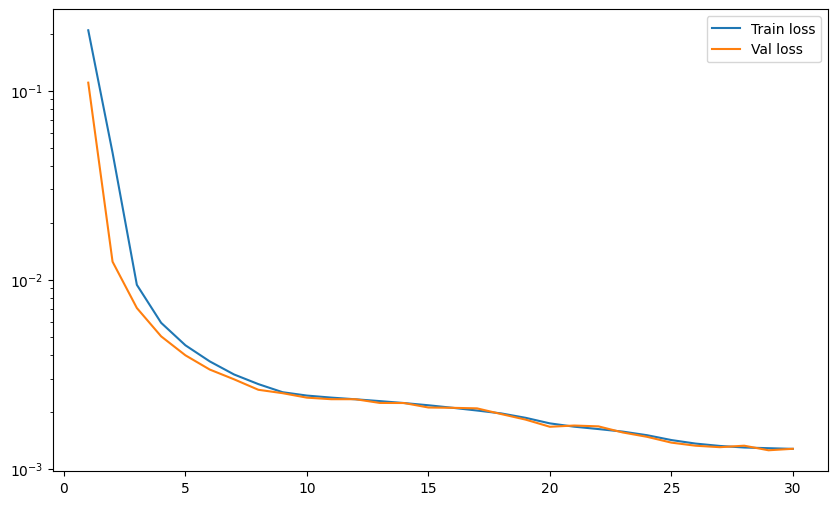

In [4]:
plt.figure(figsize=(10,6))
plt.plot(np.arange(1, num_epochs+1), avg_t_loss_s, label="Train loss")
plt.plot(np.arange(1, num_epochs+1), avg_v_loss_s, label="Val loss")
plt.yscale('log')
plt.savefig("training.png")
plt.legend()
plt.close

if True:
    torch.save({
        'model_state_dict': model.state_dict(),
        'y_mean': y_mean,
        'y_std':  y_std,
        }, 'bandpass_NN_v1.pth')

In [5]:
#Evaluation on the Test Set

model = NeuralNet()    # instantiate architecture first
model_setup_dict = torch.load('bandpass_NN_v1.pth', map_location=device)
model.load_state_dict(model_setup_dict['model_state_dict'])
y_std, y_mean = model_setup_dict['y_std'], model_setup_dict['y_mean'] 
model.to(device)
model.eval()


NeuralNet(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
)

In [6]:
with torch.no_grad():
    # Single sample
    errs = []
    total_val_loss = 0
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)  # move inputs to GPU
        y_batch = y_batch.to(device)  # move targets to GPU
        X_b0 = X_batch[0]
        pred_norm = model(X_b0)
        pred = pred_norm * y_std + y_mean           # denormalize output
        err = abs((pred - y_batch[0].item()))/y_batch[0].item()
        print(f"Params: [{X_b0[0]}, {X_b0[1]}, {X_b0[2]}], Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
        errs.append(err)
        loss  = criterion(pred, y_batch)
        total_val_loss += loss.item() * len(y_batch)

Params: [-10.0, 1.600000023841858, 10.0], Preds = 861.9269, True = 863.6838, err = 0.002034116812138132
Params: [-10.0, 1.7428570985794067, 13.428571701049805], Preds = 861.9942, True = 861.5145, err = 0.0005567909368230601
Params: [-10.0, 1.914285659790039, 12.666666984558105], Preds = 861.4041, True = 860.8893, err = 0.0005979528632609659
Params: [-10.0, 2.085714340209961, 11.904762268066406], Preds = 860.8140, True = 860.3010, err = 0.0005962971677712363
Params: [-9.047618865966797, 1.6285713911056519, 11.142857551574707], Preds = 862.5796, True = 862.7502, err = 0.0001978454537542417
Params: [-9.047618865966797, 1.7999999523162842, 10.380952835083008], Preds = 861.9895, True = 862.0972, err = 0.00012494404863376738
Params: [-9.047618865966797, 1.9428571462631226, 13.809523582458496], Preds = 861.8930, True = 861.9274, err = 3.9987177756532924e-05
Params: [-9.047618865966797, 2.114285707473755, 13.047618865966797], Preds = 861.3029, True = 861.5473, err = 0.00028371711391814045
Para

/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


torch.Size([10000, 3])
torch.Size([100, 100])
(10000,)


/tmp/ipykernel_12812/1272668489.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


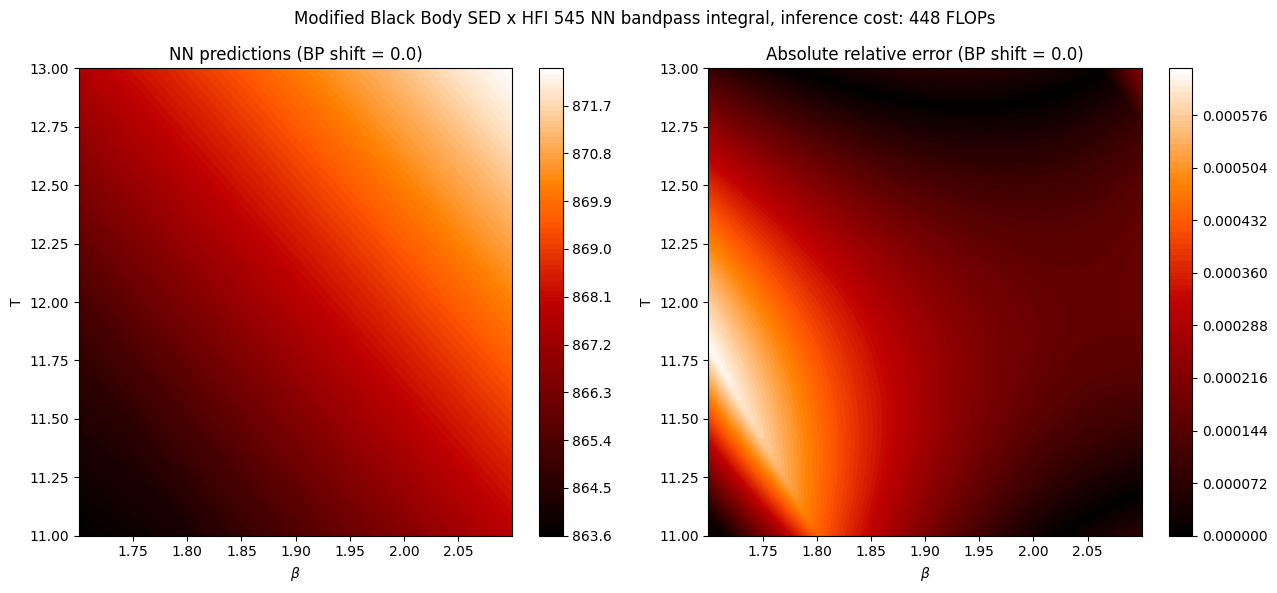

In [ ]:
samp_intervals = {
    "BP_shift":(-10., 10.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s_fixed = 0.0 

grid_b, grid_t = torch.meshgrid(beta_s, t_s, indexing='ij')

X_grid = torch.stack([
    torch.full((N_vals*N_vals,), bp_s_fixed),
    grid_b.flatten(),
    grid_t.flatten()
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
batch_size = 1024
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(bp_s_fixed, X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))

print(X_grid.shape)
print(preds_grid.shape)
print(np.array(all_true).shape)
trues_grid=np.array(all_true).reshape((N_vals,N_vals))


#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.FLOPs_count()} FLOPs")
cf = ax[0].contourf(
    grid_b.numpy(),         # x axis  shape: (100, 100)
    grid_t.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel('T')
ax[0].set_title(f'NN predictions (BP shift = {bp_s_fixed})')

cf = ax[1].contourf(
    grid_b.numpy(),       # x axis  shape: (100, 100)
    grid_t.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel('T')
ax[1].set_title(f'Absolute relative error (BP shift = {bp_s_fixed})')
plt.tight_layout()
plt.show()